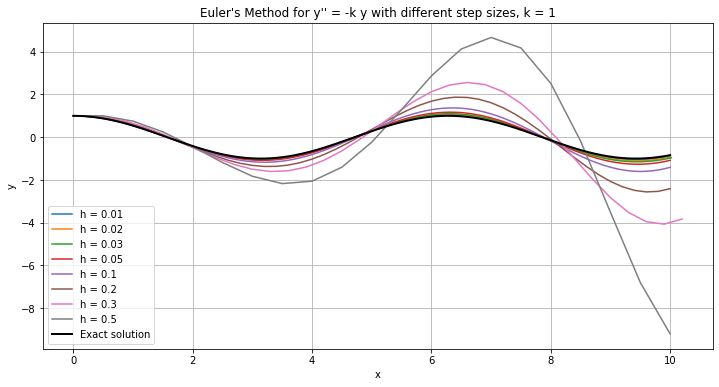

For k = 1
h = 0.01, max |y| = 1.048264
h = 0.02, max |y| = 1.098871
h = 0.03, max |y| = 1.151926
h = 0.05, max |y| = 1.265927
h =  0.1, max |y| = 1.602690
h =  0.2, max |y| = 2.560074
h =  0.3, max |y| = 4.067924
h =  0.5, max |y| = 9.206092


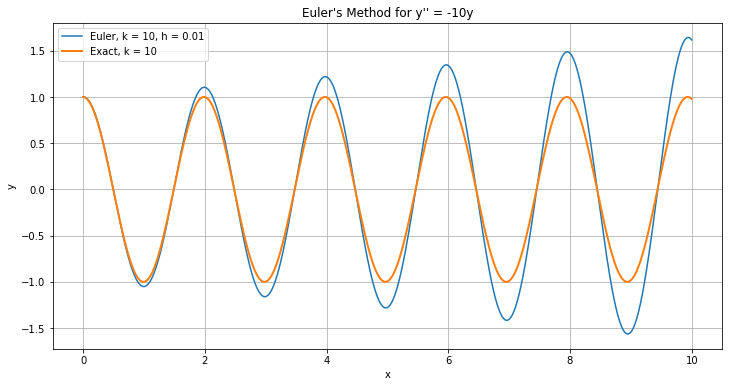


For k = 10, h = 0.01
max |y| = 1.643338


In [2]:
# Mrinal Pradhan
# Challenge 17

import numpy as np
import matplotlib.pyplot as plt

def euler_oscillator(k, h, x_start, x_end, y_0, v_0):
    x_values = np.arange(x_start, x_end + h, h)
    y_values = np.zeros(len(x_values))
    v_values = np.zeros(len(x_values))

    y_values[0] = y_0
    v_values[0] = v_0

    for i in range(1, len(x_values)):
        y_n = y_values[i - 1]
        v_n = v_values[i - 1]

        # Euler updates
        y_values[i] = y_n + h * v_n
        v_values[i] = v_n + h * (-k * y_n)

    return x_values, y_values, v_values


# Exact solution
def exact_solution(k, x):
    y_exact = np.cos(np.sqrt(k) * x)
    v_exact = -np.sqrt(k) * np.sin(np.sqrt(k) * x)
    return y_exact, v_exact


# Parameters
x_start = 0
x_end = 10
y_0 = 1.0
v_0 = 0.0
k = 1.0

# Step sizes to test
h_values = [0.01, 0.02, 0.03, 0.05, 0.1, 0.2, 0.3, 0.5]

# Plot all Euler position curves
plt.figure(figsize=(12, 6))

for h in h_values:
    x_vals, y_vals, v_vals = euler_oscillator(k, h, x_start, x_end, y_0, v_0)
    plt.plot(x_vals, y_vals, label=f"h = {h}")

# Exact solution
x_exact = np.linspace(x_start, x_end, 2000)
y_exact, v_exact = exact_solution(k, x_exact)
plt.plot(x_exact, y_exact, color='black', linewidth=2, label='Exact solution')

plt.xlabel("x")
plt.ylabel("y")
plt.title("Euler's Method for y'' = -k y with different step sizes, k = 1")
plt.legend()
plt.grid(True)
plt.show()

# Print max |y| for each h
print("For k = 1")
for h in h_values:
    x_vals, y_vals, v_vals = euler_oscillator(k, h, x_start, x_end, y_0, v_0)
    print(f"h = {h:>4}, max |y| = {np.max(np.abs(y_vals)):.6f}")

# Now test k = 10, h = 0.01-
k = 10
h = 0.01

x_vals, y_vals, v_vals = euler_oscillator(k, h, x_start, x_end, y_0, v_0)
x_exact = np.linspace(x_start, x_end, 2000)
y_exact, v_exact = exact_solution(k, x_exact)

plt.figure(figsize=(12, 6))
plt.plot(x_vals, y_vals, label="Euler, k = 10, h = 0.01")
plt.plot(x_exact, y_exact, label="Exact, k = 10", linewidth=2)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Euler's Method for y'' = -10y")
plt.legend()
plt.grid(True)
plt.show()

print("\nFor k = 10, h = 0.01")
print(f"max |y| = {np.max(np.abs(y_vals)):.6f}")

In [ ]:
# Yes it becomes unstable and it starts becoming unstable around h = 0.1.
# As k increases, the waves get faster.
# Larger h does not work well, Euler becomes very inaccurate and unstable.